(0d-nb)=
# Tight-binding model of $\text{NH}_3$ molecule

In [1]:
from pythtb import TBModel, Lattice
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define lattice vectors
lat_vecs = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
# define coordinates of orbitals
orb_vecs = [
    [(2 / 3) * np.sqrt(3)/2, 0, 0],
    [(-1 / 3) * np.sqrt(3)/2, 1/2, 0],
    [(-1 / 3) * np.sqrt(3)/2, -1/2, 0],
    [0, 0, 1],
]

lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=None)

In [3]:
# make zero dimensional tight-binding model
my_model = TBModel(lattice=lat, nspin=1)

# set model parameters
delta = 0.5
t_first = 1.0

# change on-site energies so that N and H don't have the same energy
my_model.set_onsite([-delta, -delta, -delta, delta])
# set hoppings (one for each connected pair of orbitals)
# (amplitude, i, j)
my_model.set_hop(t_first, 0, 1)
my_model.set_hop(t_first, 0, 2)
my_model.set_hop(t_first, 0, 3)
my_model.set_hop(t_first, 1, 2)
my_model.set_hop(t_first, 1, 3)
my_model.set_hop(t_first, 2, 3)

print(my_model)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 3
k-space dimension           = 0
periodic directions         = []
number of orbitals          = 4
number of spin components   = 1
number of electronic states = 4

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000,  0.000]
  # 1 ===> [ 0.000,  1.000,  0.000]
  # 2 ===> [ 0.000,  0.000,  1.000]
Volume of unit cell (Cartesian) = 1.000 [A^d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.577,  0.000,  0.000]
  # 1 ===> [-0.289,  0.500,  0.000]
  # 2 ===> [-0.289, -0.500,  0.000]
  # 3 ===> [ 0.000,  0.000,  1.000]
Orbital vectors (fractional):
  # 0 ===> [ 0.577,  0.000,  0.000]
  # 1 ===> [-0.289,  0.500,  0.000]
  # 2 ===> [-0.289, -0.500,  0.000]
  # 3 ===> [ 0.000,  0.000,  1.000]
----------------------------------------
Site energies:
  # 0 ===> -0.500 
  # 1 ===> -0.500 
  # 2 ===> -0.500 
  # 3 ===>  0.500 
Hoppings:
  < 0 | H 

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

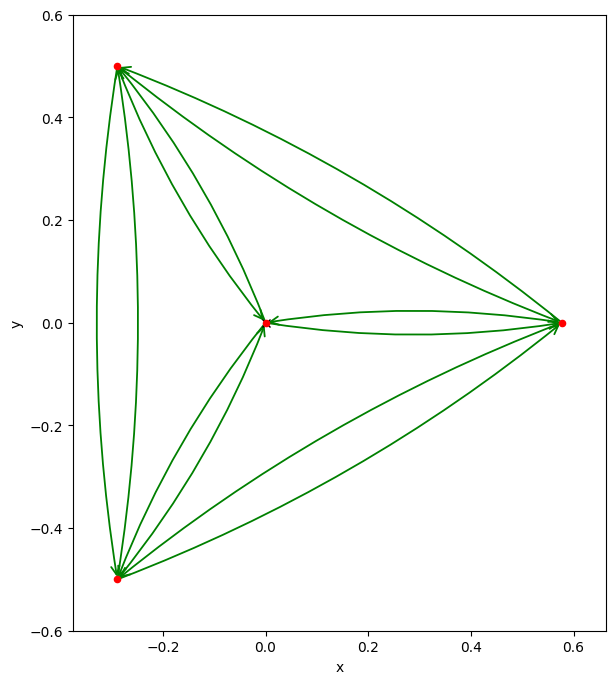

In [4]:
my_model.visualize()

Solve for the eigenenergies of the Hamiltonian

In [5]:
evals = my_model.solve_ham()

Text(0, 0.5, 'Energy')

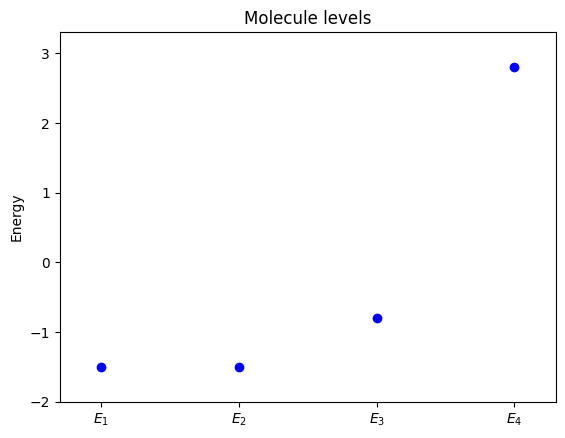

In [6]:
fig, ax = plt.subplots()

ax.plot(evals, "bo")

ax.set_xticks(range(len(orb_vecs)))
ax.set_xticklabels([r"$E_1$", r"$E_2$", r"$E_3$", r"$E_4$"])
ax.set_xlim(-0.3, 3.3)
ax.set_ylim(evals.min() - 0.5, evals.max() + 0.5)

ax.set_title("Molecule levels")
ax.set_ylabel("Energy")